# Beta Spectrum Calculator — Theory Core

Demonstrates the `beta_spectrum` theoretical shape calculator: building spectra from physics corrections, comparing transition types, composing branch contributions.

All spectra are built via `BranchConfig` — even a single branch is a one-element list. The `BetaSpectrum` orchestrates multiplicative composition of corrections and intensity-weighted summation of branch contributions.

Physics model:

$$N(W) = p \cdot W \cdot (W_0 - W)^2 \times \prod_i C_i(W)$$\n
where $C_i$ are the correction factors: Fermi function, finite nuclear size, screening, exchange, radiative, and the forbiddenness-dependent phase space factor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from beta_spectrum import (
    BetaSpectrum,
    SpectrumConfig,
    BranchConfig,
    BetaSpectrumAnalyzer,
    PhaseSpace,
    FermiFunction,
    FiniteSizeL0,
    ChargeDistributionU,
    ScreeningCorrection,
    ExchangeCorrection,
    RadiativeCorrection,
    T_to_W,
    W_to_T,
    momentum,
    ME_MEV,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"beta-spectrum version: {__import__('beta_spectrum').__version__}")
print(f"ME = {ME_MEV:.9f} MeV")

beta-spectrum version: 0.3.0
ME = 0.510998950 MeV


## 1. Total Spectrum — Tc-99 Ground State

Tc-99 beta-minus decay to Ru-99 ground state:
- Z_parent = 43, Z_daughter = 44, A = 99
- Q ≈ 294 keV (0.294 MeV)
- Transition: 2nd-forbidden unique (F2)

The `SpectrumConfig` is a declarative dataclass. Even for a single decay channel, we use a `BranchConfig` list — a one-element list is the trivial case of branch composition.

In [2]:
# Tc-99 config — one branch (ground state)
config = SpectrumConfig(
    Z_parent=43,
    Z_daughter=44,
    A_number=99,
    endpoint_MeV=0.294,
    transition_type="F2",
    e_step_MeV=0.001,
    use_phase_space=True,
    use_fermi=True,
    use_screening=True,
    use_finite_size=True,
    use_charge_dist=True,
    use_exchange=True,
    use_radiative=True,
    branches=[BranchConfig(endpoint_MeV=0.294, transition_type="F2", intensity=1.0)],
)

spectrum = BetaSpectrum.from_config(config)

# Energy grid: get_energy_grid returns kinetic energy in MeV
W, T_MeV = spectrum.get_energy_grid(config)
T_keV = T_MeV * 1000  # convert to keV
W0_keV = W_to_T(T_to_W(config.endpoint_MeV)) * 1000  # endpoint in keV

print("Energy grid: {} points, {:.1f} - {:.1f} keV".format(len(T_keV), T_keV[0], T_keV[-1]))
print("Endpoint: {:.1f} keV".format(W0_keV))

Energy grid: 293 points, 1.0 - 293.0 keV
Endpoint: 294.0 keV


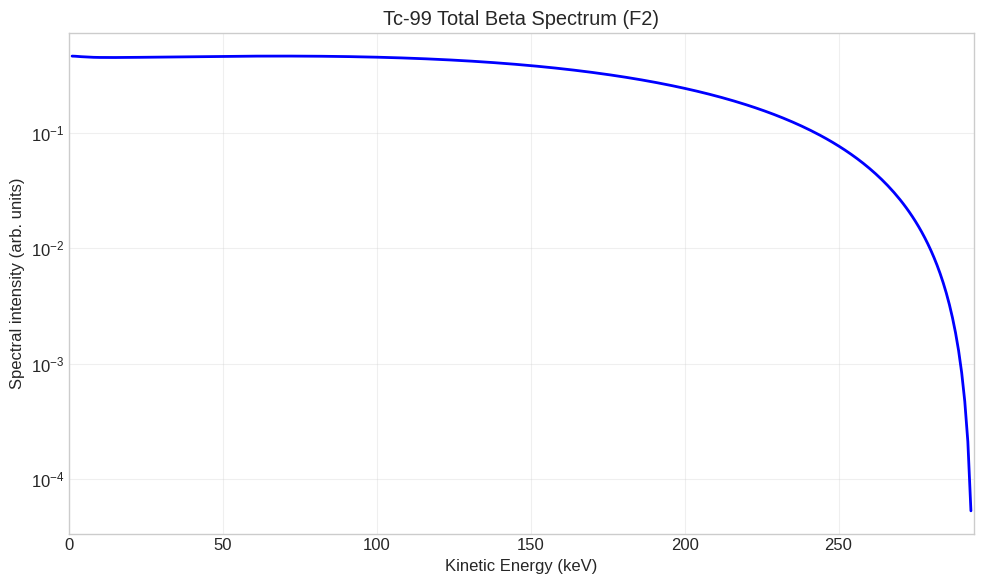

In [3]:
# Evaluate total spectrum
total_spectrum = spectrum(W)

# Plot
fig, ax = plt.subplots()
ax.plot(T_keV, total_spectrum, "b-", linewidth=2)
ax.set_xlabel("Kinetic Energy (keV)")
ax.set_ylabel("Spectral intensity (arb. units)")
ax.set_title("Tc-99 Total Beta Spectrum (F2)")
ax.set_xlim(0, W0_keV)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Individual Correction Factors

Each `SpectrumComponent` is a multiplicative factor. Decomposing the total spectrum shows how each correction modifies the bare phase space.

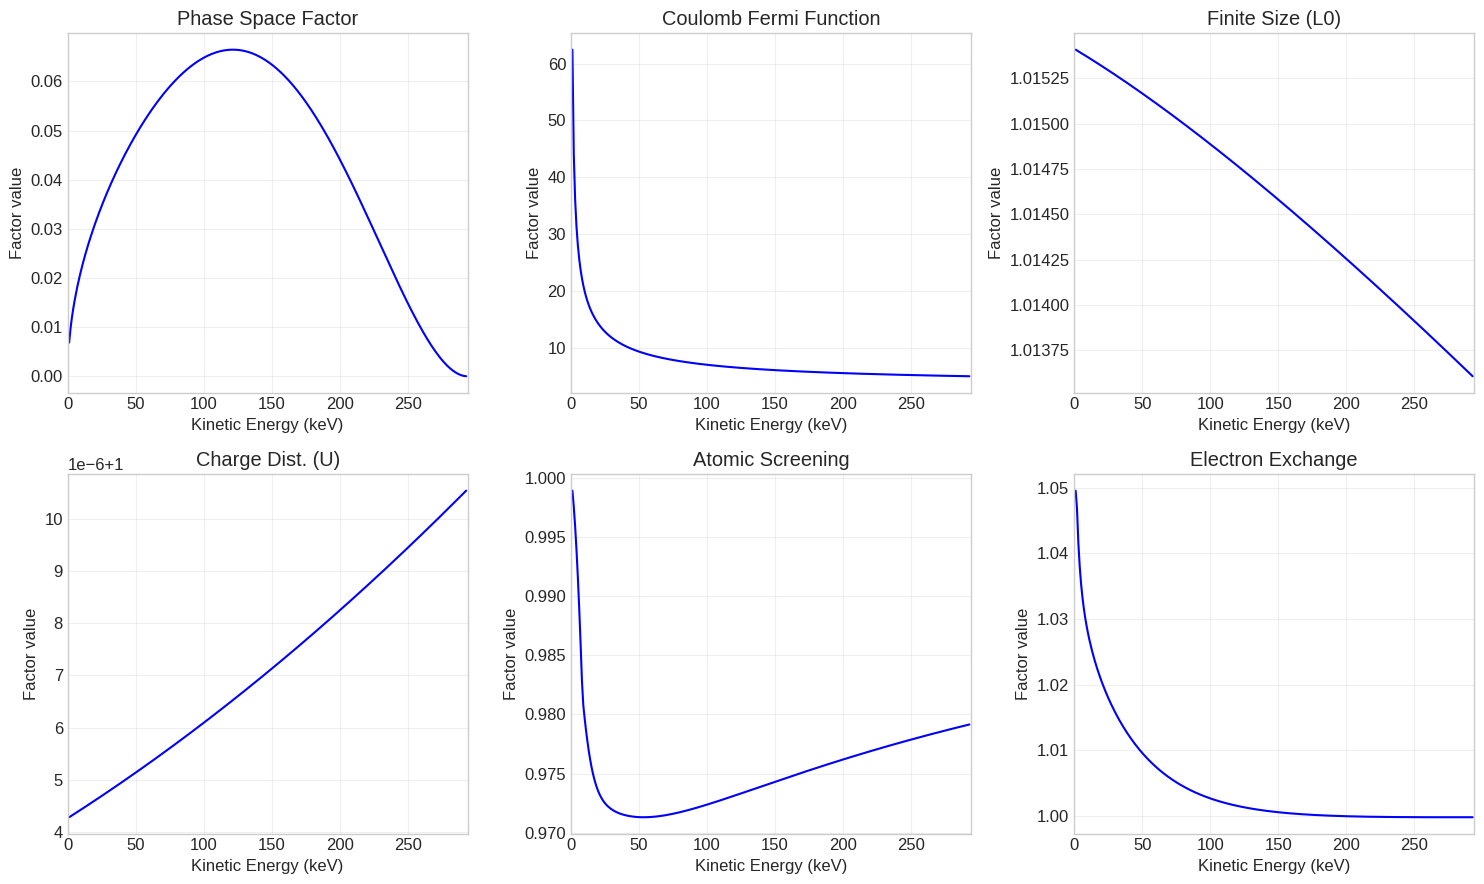

In [4]:
# Calculate individual components
components = spectrum.calculate_components(W)

# Plot each component's multiplicative factor
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

component_plots = [
    ("PhaseSpace", "Phase Space Factor", axes[0]),
    ("Fermi", "Coulomb Fermi Function", axes[1]),
    ("FiniteSizeL0", "Finite Size (L0)", axes[2]),
    ("ChargeDistributionU", "Charge Dist. (U)", axes[3]),
    ("Screening", "Atomic Screening", axes[4]),
    ("Exchange", "Electron Exchange", axes[5]),
]

for name, title, ax in component_plots:
    if name in components:
        ax.plot(T_keV, components[name], "b-", linewidth=1.5)
        ax.set_xlabel("Kinetic Energy (keV)")
        ax.set_ylabel("Factor value")
        ax.set_title(title)
        ax.set_xlim(0, W0_keV)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Radiative Correction

Outer radiative correction (Sirlin 1967/1987) with soft-photon resummation. Typically ~1% for low-energy beta decays.

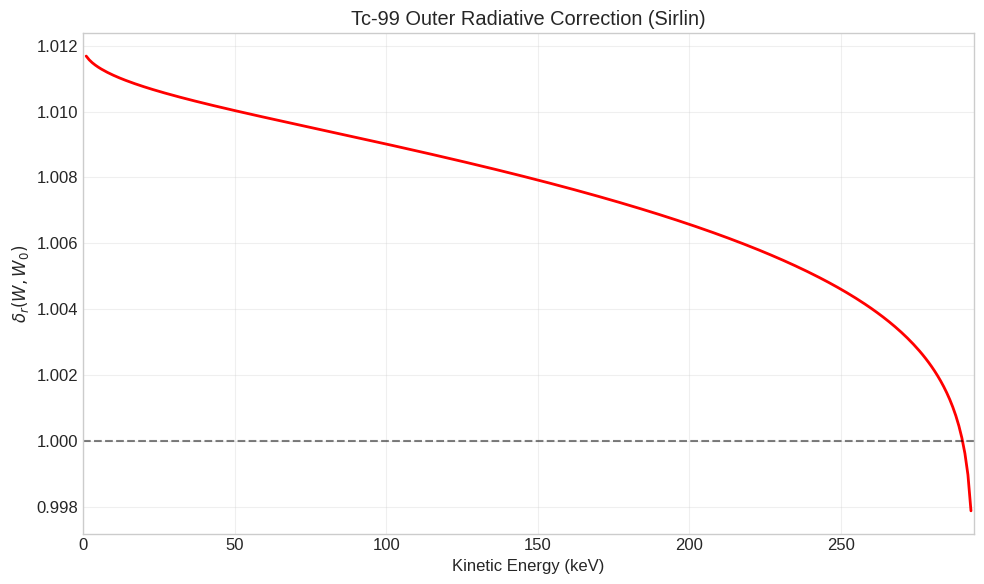

In [5]:
fig, ax = plt.subplots()
ax.plot(T_keV, components["Radiative"], "r-", linewidth=2)
ax.axhline(1.0, color="k", linestyle="--", alpha=0.5)
ax.set_xlabel("Kinetic Energy (keV)")
ax.set_ylabel(r"$\delta_r(W, W_0)$")
ax.set_title("Tc-99 Outer Radiative Correction (Sirlin)")
ax.set_xlim(0, W0_keV)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forbiddenness Types — Phase Space Comparison

The transition type determines the momentum-dependent forbiddenness factor:

| Type | Forbiddenness | Forbid. Factor |
|------|--------------|----------------|
| A | Allowed | 1 |
| F1 | 1st forbidden non-unique | 1 |
| F1U | 1st forbidden unique | $p_\nu^2 + p_e^2$ |
| F2 | 2nd forbidden | $p_\nu^2 + p_e^2$ |
| F2U | 2nd forbidden unique | $p_\nu^4 + 0.3 p_\nu^2 p_e^2 + p_e^4$ |
| F3 | 3rd forbidden | $p_\nu^4 + 0.3 p_\nu^2 p_e^2 + p_e^4$ |
| F3U | 3rd forbidden unique | $p_\nu^6 + 7 p_\nu^4 p_e^2 + 7 p_\nu^2 p_e^4 + p_e^6$ |
| F4 | 4th forbidden | $p_\nu^6 + 7 p_\nu^4 p_e^2 + 7 p_\nu^2 p_e^4 + p_e^6$ |

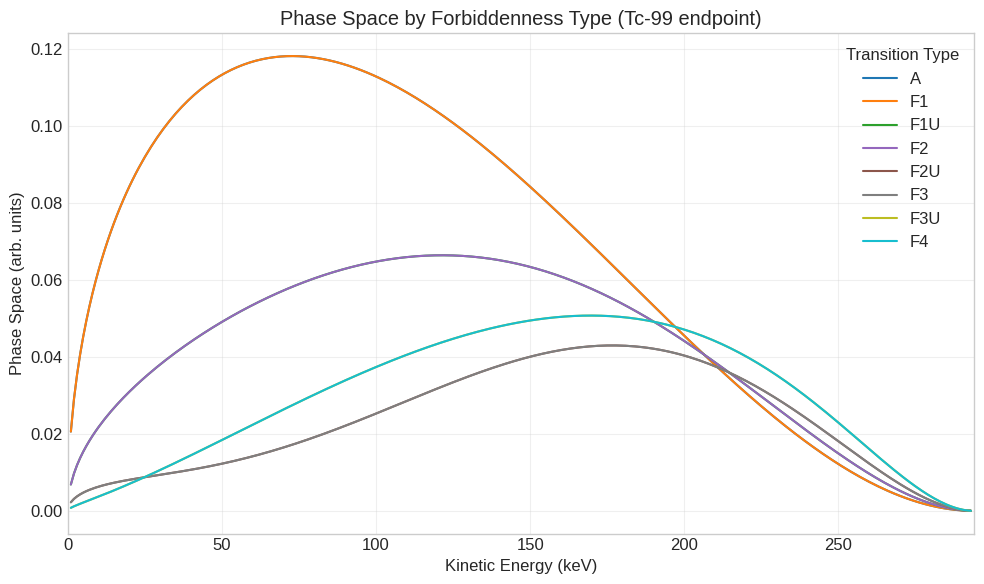

In [6]:
# Compare phase space factors for different transition types
transition_types = ['A', 'F1', 'F1U', 'F2', 'F2U', 'F3', 'F3U', 'F4']
W0 = T_to_W(0.294)  # same endpoint in m_e units

fig, ax = plt.subplots()
colors = plt.cm.tab10(np.linspace(0, 1, len(transition_types)))

for i, tr_type in enumerate(transition_types):
    ps = PhaseSpace(W0=W0, transition_type=tr_type)
    phase_space = ps(W)
    ax.plot(T_keV, phase_space, label=tr_type, color=colors[i], linewidth=1.5)

ax.set_xlabel("Kinetic Energy (keV)")
ax.set_ylabel("Phase Space (arb. units)")
ax.set_title("Phase Space by Forbiddenness Type (Tc-99 endpoint)")
ax.legend(title="Transition Type")
ax.set_xlim(0, W0_keV)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Branch Contributions

Tc-99 has multiple decay branches to different excited states of Ru-99. Each branch has its own endpoint energy, transition type, and branching intensity.

The architecture separates:
- **Branch-dependent components** (PhaseSpace, Radiative) — per-branch calculators
- **Universal components** (Fermi, screening, finite size, exchange) — single multiplicative layer

The total spectrum is the intensity-weighted sum of branch spectra, each masked to zero beyond its own endpoint (physically necessary).

In [7]:
branches = [
    BranchConfig(endpoint_MeV=0.294, transition_type="F2", intensity=0.98),
    BranchConfig(endpoint_MeV=0.200, transition_type="F2U", intensity=0.015),
    BranchConfig(endpoint_MeV=0.120, transition_type="A",   intensity=0.005),
]

multi_config = SpectrumConfig(
    Z_parent=43,
    Z_daughter=44,
    A_number=99,
    endpoint_MeV=0.294,
    transition_type="F2",
    e_step_MeV=0.001,
    branches=branches,
    intensity_cutoff=0.0,
)

multi_spectrum = BetaSpectrum.from_config(multi_config)

for i, b in enumerate(branches):
    print("  Branch {}: E0={} keV, type={}, intensity={:.3f}".format(
        i+1, b.endpoint_MeV*1000, b.transition_type, b.intensity))

  Branch 1: E0=294.0 keV, type=F2, intensity=0.980
  Branch 2: E0=200.0 keV, type=F2U, intensity=0.015
  Branch 3: E0=120.0 keV, type=A, intensity=0.005


In [8]:
from beta_spectrum import W_to_T, T_to_W

W, T_MeV = multi_spectrum.get_energy_grid(multi_config)
T_keV = T_MeV * 1000
W0_max_keV = W_to_T(T_to_W(max(b.endpoint_MeV for b in branches))) * 1000

total = multi_spectrum(W)

print("Grid: {} points, {:.1f} - {:.1f} keV".format(len(T_keV), T_keV[0], T_keV[-1]))
print("Max endpoint: {:.1f} keV".format(W0_max_keV))

Grid: 293 points, 1.0 - 293.0 keV
Max endpoint: 294.0 keV


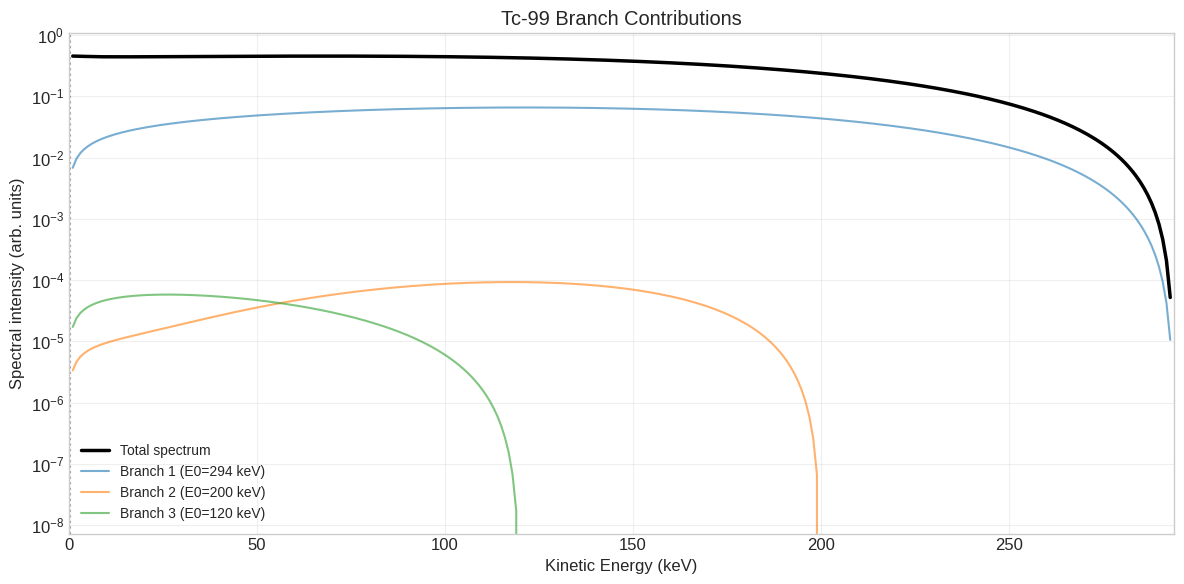

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(T_keV, total, "k-", linewidth=2.5, label="Total spectrum")

branch_spectra = multi_spectrum.get_branch_normalized_spectra(W)
for i, bs in enumerate(branch_spectra):
    ax.plot(T_keV, bs, alpha=0.6, linewidth=1.5,
            label="Branch {} (E0={:.0f} keV)".format(i+1, branches[i].endpoint_MeV*1000))

for i, b in enumerate(branches):
    br_end_keV = W_to_T(T_to_W(b.endpoint_MeV))
    ax.axvline(br_end_keV, color="gray", linestyle=":", alpha=0.5)

ax.set_xlabel("Kinetic Energy (keV)")
ax.set_ylabel("Spectral intensity (arb. units)")
ax.set_title("Tc-99 Branch Contributions")
ax.set_yscale("log")
ax.legend(fontsize=10)
ax.set_xlim(0, W0_max_keV)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Component Decomposition

`calculate_components()` returns universal components + per-branch branch-dependent components.

In [10]:
components_multi = multi_spectrum.calculate_components(W)

print("Available component keys:")
for key in sorted(components_multi.keys()):
    print("  {}".format(key))

Available component keys:
  ChargeDistributionU
  Exchange
  Fermi
  FiniteSizeL0
  Screening
  branch_0.PhaseSpace
  branch_0.Radiative
  branch_1.PhaseSpace
  branch_1.Radiative
  branch_2.PhaseSpace
  branch_2.Radiative


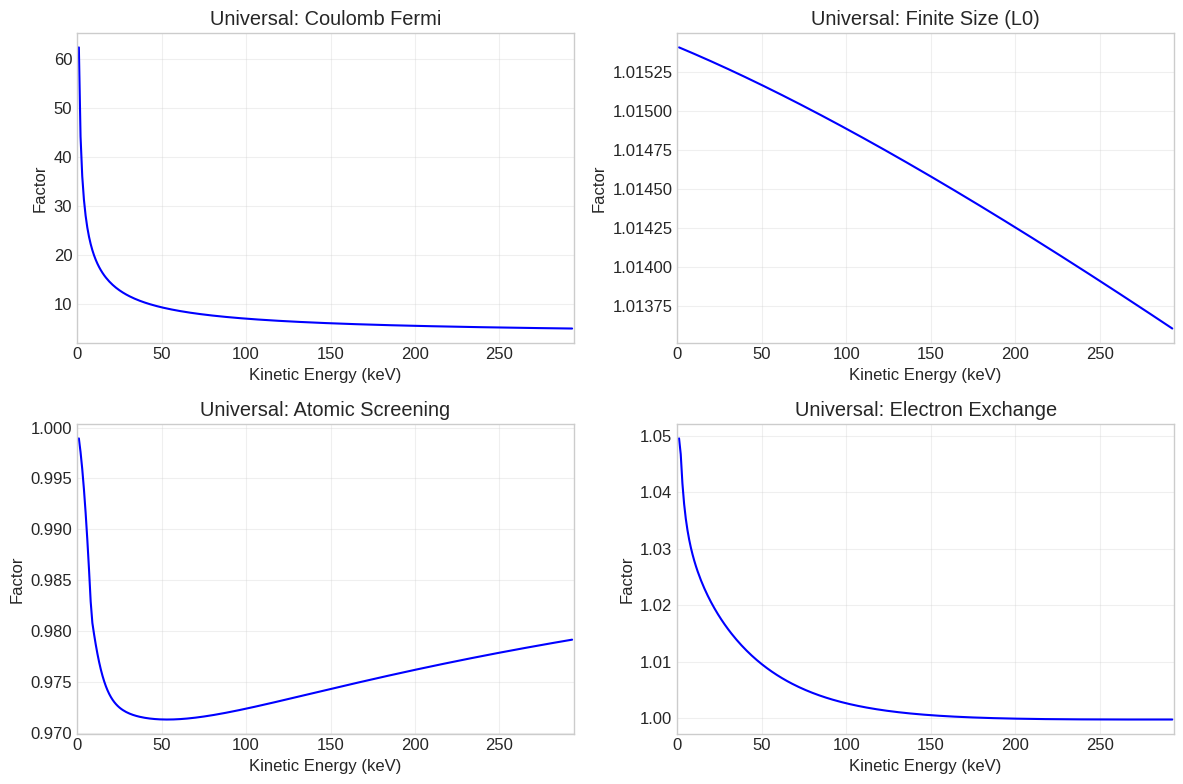

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

universal_keys = ["Fermi", "FiniteSizeL0", "Screening", "Exchange"]
universal_titles = ["Coulomb Fermi", "Finite Size (L0)", "Atomic Screening", "Electron Exchange"]

for key, title, ax in zip(universal_keys, universal_titles, axes):
    if key in components_multi:
        ax.plot(T_keV, components_multi[key], "b-", linewidth=1.5)
        ax.set_xlabel("Kinetic Energy (keV)")
        ax.set_ylabel("Factor")
        ax.set_title("Universal: {}".format(title))
        ax.set_xlim(0, W0_max_keV)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Visualization and Export

`BetaSpectrumAnalyzer` provides unified plotting for the branch decomposition and CSV export with metadata headers.

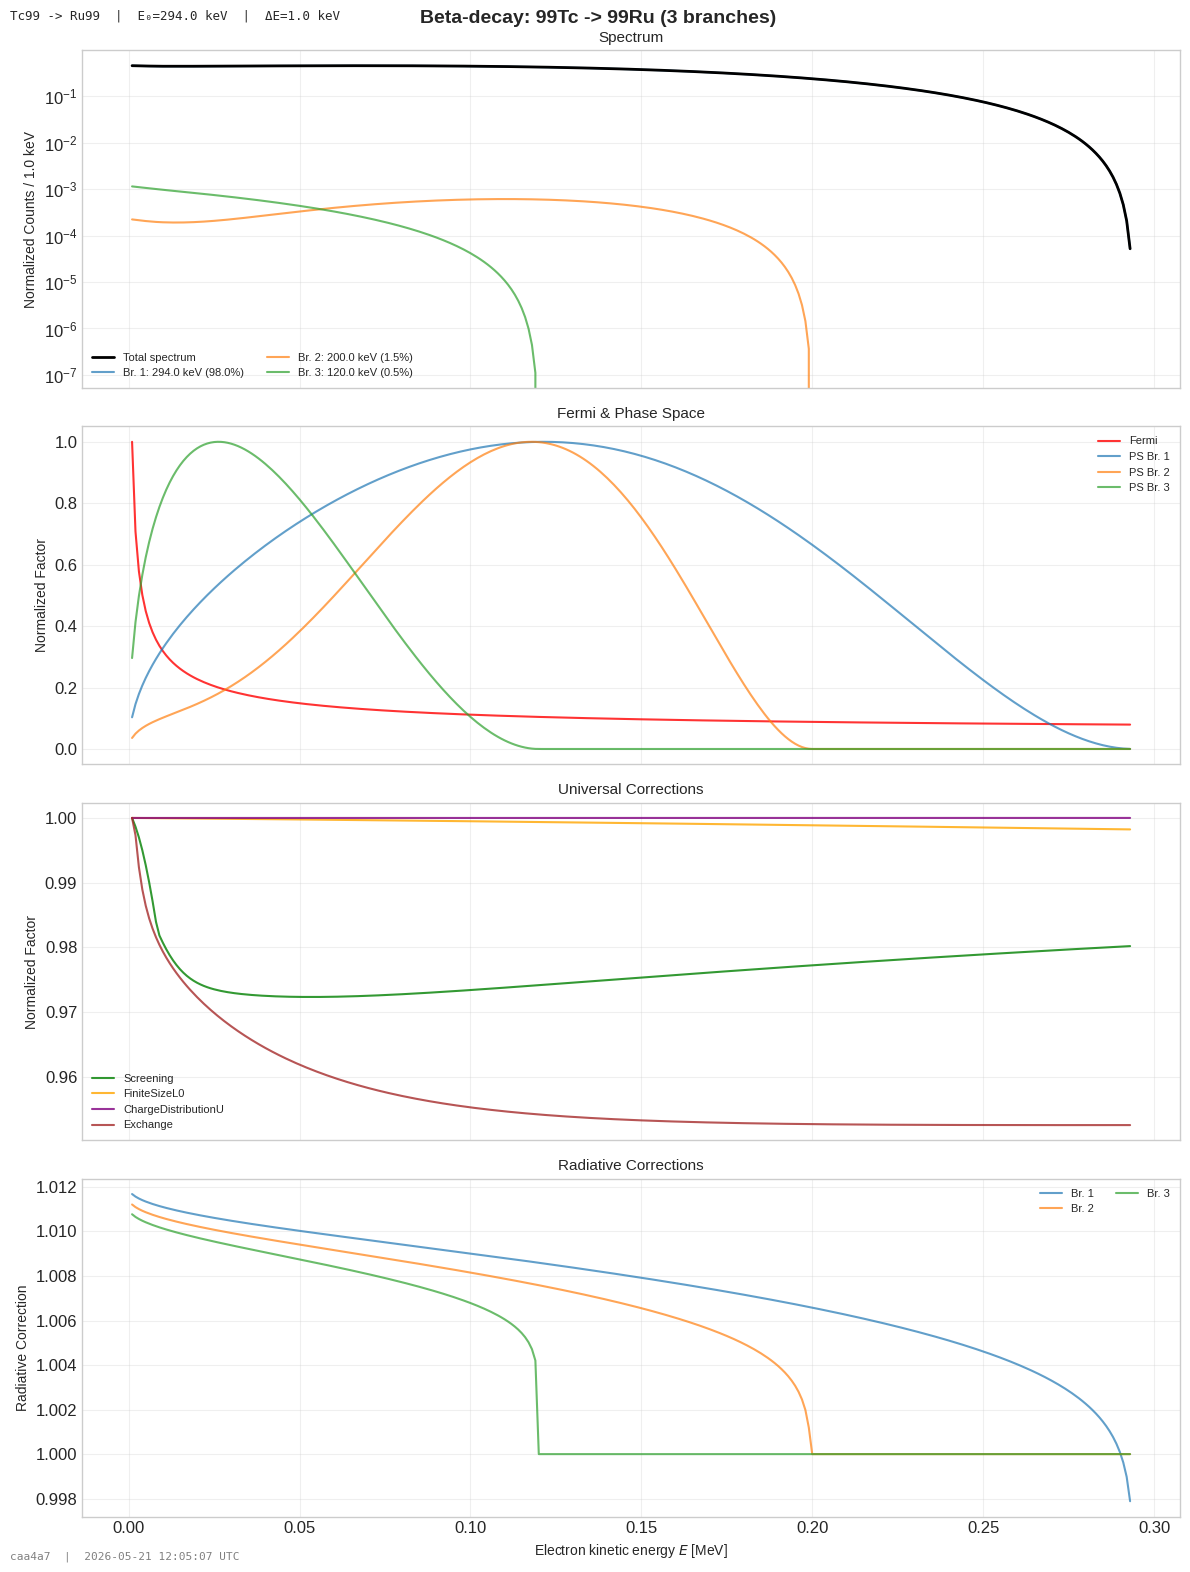

In [12]:
analyzer = BetaSpectrumAnalyzer(multi_spectrum, multi_config)
analyzer.plot_analysis(show_components=True)

## 6. Key Takeaways

1. **Factory pattern**: `BetaSpectrum.from_config()` creates per-branch calculators for branch-dependent components (PhaseSpace, Radiative) and a shared layer for universal components (Fermi, screening, finite size, exchange).
2. **Composite pattern**: Each `BetaSpectrum` is a composition of `SpectrumComponent` objects with a uniform `__call__(W)` interface.
3. **Energy units**: `get_energy_grid()` returns kinetic energy in **MeV** — multiply by 1000 for keV. The `W` grid is in m_e units (total energy = kinetic/m_e + 1).
4. **Branch composition**: Total spectrum = universal_factors × Σ(intensity_i × branch_i). Each branch is masked to zero beyond its endpoint via `np.where`.
5. **Version note**: `__init__.py` declares version `0.3.0` while `pyproject.toml` says `0.4.0` — a known discrepancy.